In [1]:
# Preámbulo: carga el CSV que produce data/ProyectoNeoRework_data.ipynb.
# Ejecutar este notebook con `notebooks/` como directorio de trabajo.

import pandas as pd
import os

ruta_csv = os.path.join("..", "data", "close_approaches.csv")

if not os.path.exists(ruta_csv):
    raise FileNotFoundError(
        f"No se encontró el CSV en {ruta_csv}. "
        f"Ejecutar primero data/ProyectoNeoRework_data.ipynb")

df_full = pd.read_csv(ruta_csv)

# Se duplica aquí (y no se importa) para que cada notebook sea autocontenido;
# debe mantenerse idéntica a la del notebook de datos.
def limpiar_fecha(fecha_str):
    if isinstance(fecha_str, str):
        return fecha_str.split("±")[0].strip()
    return fecha_str

df_full["Close-Approach (CA) Date"] = df_full["Close-Approach (CA) Date"].apply(limpiar_fecha)

# ANÁLISIS PRINCIPAL: solo eventos posteriores al descubrimiento del objeto.
# Los anteriores son integraciones numéricas hacia atrás, no observaciones.
# `df_full` se conserva solo para el conteo comparativo de abajo (cuánto
# del catálogo es retroactivo). El efecto de incluir esos eventos en el
# proxy MOID (r sube de 0.868 a 0.931) está cuantificado fuera de este
# notebook, en docs/05-discrepancias.md (discrepancia F).
df = df_full[df_full["post_discovery"] == 1].copy()

# Tres cantidades independientes. Se excluyen Diameter(km) (imputado desde H
# mediante D=1329·10^(-0.2H)/√0.14) y V relative (deducible de V infinity y la
# distancia): ambas son funciones deterministas de las demás y su inclusión
# degeneraba el PCA. Las columnas oficiales de la SBDB (MOID, H_SBDB,
# PHA_official) NUNCA entran aquí: solo etiquetan y validan.
features = ["CA DistanceNominal (au)", "V infinity(km/s)", "H(mag)"]

print(f"Catálogo completo : {len(df_full):,} eventos, {df_full['Object'].nunique():,} objetos")
print(f"Solo observado    : {len(df):,} eventos, {df['Object'].nunique():,} objetos "
      f"({100*len(df)/len(df_full):.1f}% de los eventos)")

Catálogo completo : 340,469 eventos, 39,074 objetos
Solo observado    : 74,530 eventos, 37,526 objetos (21.9% de los eventos)


In [2]:
df

,Object,Close-Approach (CA) Date,CA DistanceNominal (au),CA DistanceMinimum (au),V relative(km/s),V infinity(km/s),H(mag),Diameter(km),Std Diameter(km),MOID (au),H_SBDB(mag),first_obs_year,data_arc(d),n_obs_used,PHA_official,post_discovery,PHA_proxy
1775,433,1900-Dec-27 01:30,0.314929,0.314929,5.578619,5.577102,10.40,16.840000,0.060000,0.149000,10.40,1893.0,46582.0,9130,0.0,1,0
13852,433,1907-Nov-05 03:31,0.471486,0.471485,4.394491,4.393205,10.40,16.840000,0.060000,0.149000,10.40,1893.0,46582.0,9130,0.0,1,0
18505,1P,1910-May-20 12:50,0.151352,0.151351,70.558993,70.558744,NaN,11.000000,3.850000,0.074500,NaN,1835.0,57852.0,8518,NaN,1,0
26344,1914 S1,1914-Sep-23 23:18,0.267137,0.201458,44.039658,44.039431,NaN,NaN,NaN,0.151000,NaN,1914.0,5.0,5,NaN,1,0
31026,433,1917-Apr-20 21:19,0.499257,0.499257,4.816784,4.815676,10.40,16.840000,0.060000,0.149000,10.40,1893.0,46582.0,9130,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340464,2014 UN114,2026-Dec-31 10:28,0.457992,0.456455,18.614288,18.613976,24.50,0.044716,0.015651,0.000647,24.50,2014.0,65.0,178,0.0,1,0
340465,2022 AP1,2026-Dec-31 13:47,0.103992,0.083884,13.884621,13.882775,28.39,0.007455,0.002609,0.000908,28.39,2022.0,5.0,19,0.0,1,0
340466,2024 AV2,2026-Dec-31 14:26,0.081792,0.081791,6.109077,6.103743,26.64,0.016690,0.005842,0.003340,26.64,2022.0,1069.0,47,0.0,1,0
340467,2015 NG13,2026-Dec-31 21:48,0.317028,0.314771,10.471216,10.470413,24.90,0.037193,0.013018,0.004550,24.90,2015.0,16.0,25,0.0,1,0


## Limpieza de datos

Inspeccionamos los nulos y eliminamos únicamente las filas con NaN en las
features observadas. Las columnas de etiquetas y metadatos (`MOID (au)`,
`PHA_official`, `first_obs_year`, ...) pueden conservar NaN — corresponden a
objetos sin match en la SBDB y se tratan más adelante, en la agregación por
objeto de la sección de clasificación.

In [2]:
# Esta celda cuenta los NaN por columna, para decidir qué limpiar a continuación.
df.isna().sum()

Object                        0
Close-Approach (CA) Date      0
CA DistanceNominal (au)       0
CA DistanceMinimum (au)       0
V relative(km/s)              0
V infinity(km/s)             18
H(mag)                      146
Diameter(km)                135
Std Diameter(km)            135
MOID (au)                     0
H_SBDB(mag)                 146
first_obs_year                0
data_arc(d)                 522
n_obs_used                    0
PHA_official                146
post_discovery                0
PHA_proxy                     0
dtype: int64

In [3]:
# Esta celda elimina las filas con NaN en las features del análisis exploratorio.
df = df.dropna(subset=features)
print(f"Filas tras limpieza: {len(df):,}")

Filas tras limpieza: 74,367


# Preparacion de modelos

El análisis tiene dos bloques:

1. **Exploratorio (no supervisado):** PCA para medir la estructura lineal y la
   redundancia entre variables, K-Means para segmentar el espacio observado en
   grupos físicamente interpretables, y t-SNE (con búsqueda de hiperparámetros)
   para visualizar la estructura no lineal.
2. **Confirmatorio (supervisado):** clasificación de peligrosidad (PHA) a nivel
   de objeto, con análisis de circularidad, validación temporal y estudio de la
   función de selección observacional (sección final del notebook).

El bloque exploratorio informa al confirmatorio: la redundancia que revela el
PCA (PC5 ≈ 0%) anticipa la poda de features colineales de la clasificación.

## PCA

El PCA (Análisis de Componentes Principales) es una técnica de reducción de dimensionalidad que transforma un conjunto de variables originales, posiblemente correlacionadas, en un nuevo conjunto de variables no correlacionadas llamadas componentes principales. Su funcionamiento se basa en identificar las direcciones del espacio de datos donde la varianza es máxima, utilizando la descomposición en autovalores y autovectores de la matriz de covarianza. De esta forma, los primeros componentes concentran la mayor cantidad de información, permitiendo proyectar los datos en un espacio de menor dimensión con mínima pérdida de variabilidad, lo que facilita su análisis, visualización y modelado.


### Librerias

In [4]:
# Esta celda importa las librerías del bloque PCA / K-Means.
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### Preparacion de datos




In [5]:
# Semilla única del proyecto: se reutiliza en PCA, K-Means, t-SNE y en la
# clasificación supervisada para que todos los resultados sean reproducibles.
random_state = 20

X = df[features]

# Imprescindible: au, km/s, mag y km viven en escalas incomparables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Dataset final: {X_scaled.shape[0]} muestras x {X_scaled.shape[1]} features")

Dataset final: 74367 muestras x 3 features


In [6]:
# Esta celda ajusta el PCA completo, imprime la varianza explicada y los loadings.
pca_full = PCA(random_state=random_state)
coords_full = pca_full.fit_transform(X_scaled)

exp_var = pca_full.explained_variance_ratio_ * 100  # fracción → porcentaje, para leer "53.3%" en vez de "0.533"
var_acum = np.cumsum(exp_var)  # acumulado (PC1, PC1+PC2, ...): cuántas componentes hacen falta para sumar X% de varianza

print("Varianza explicada por componente:")
for i, var in enumerate(exp_var):
    print(f"  PC{i+1}: {var:.1f}%")
print(f"\nAcumulado PC1+PC2: {var_acum[1]:.1f}%")

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)
print("\nLoadings (contribución de cada variable):")
print(loadings.round(3))

for pc in ["PC1", "PC2"]:
    top = loadings[pc].abs().sort_values(ascending=False).head(2)
    print(f"\n{pc} -> dominado por: {', '.join(top.index)}")

PCA_UMBRAL = 80.0  # umbral convencional: por debajo, la proyección 2D pierde demasiada varianza para resumir el espacio
pca_suficiente = var_acum[1] >= PCA_UMBRAL
print(f"\n{'✓' if pca_suficiente else '✗'} PCA {'suficiente' if pca_suficiente else 'insuficiente'} "
      f"(PC1+PC2={var_acum[1]:.1f}% {'≥' if pca_suficiente else '<'} {PCA_UMBRAL:.0f}%)")

coords_2d = coords_full[:, :2]  # nos quedamos solo con PC1 y PC2 (las 2 primeras columnas) para graficar en 2D

Varianza explicada por componente:
  PC1: 53.3%
  PC2: 24.8%
  PC3: 21.9%

Acumulado PC1+PC2: 78.1%

Loadings (contribución de cada variable):
                           PC1    PC2    PC3
CA DistanceNominal (au)  0.547  0.837 -0.012
V infinity(km/s)         0.593 -0.377  0.712
H(mag)                  -0.591  0.397  0.702

PC1 -> dominado por: V infinity(km/s), H(mag)

PC2 -> dominado por: CA DistanceNominal (au), H(mag)

✗ PCA insuficiente (PC1+PC2=78.1% < 80%)


### Visualizacion

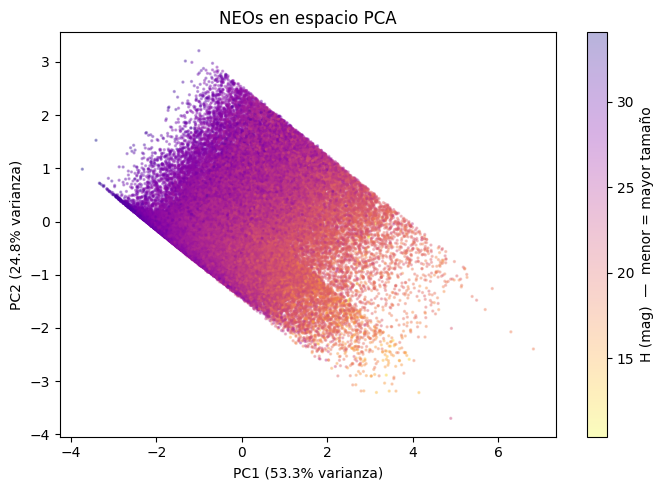

PCA insuficiente. Se aplicara K-Means sobre las dimensiones originales.


In [7]:
# Esta celda dibuja la proyección PCA coloreada por tamaño (H).
plt.figure(figsize=(7, 5))
# Color por H: menor H = objeto mas grande, de ahi la escala invertida
plt.scatter(coords_2d[:, 0], coords_2d[:, 1],
            c=X["H(mag)"], cmap="plasma_r", s=2, alpha=0.3)
plt.colorbar(label="H (mag)  —  menor = mayor tamaño")
plt.title("NEOs en espacio PCA")
plt.xlabel(f"PC1 ({exp_var[0]:.1f}% varianza)")
plt.ylabel(f"PC2 ({exp_var[1]:.1f}% varianza)")
plt.tight_layout()
plt.savefig("../results/figures/pca_scatter.png", dpi=110)  # figura del paper
plt.show()

if pca_suficiente:
    print("PCA captura suficiente varianza. Los loadings revelan la estructura fisica.")
else:
    print("PCA insuficiente. Se aplicara K-Means sobre las dimensiones originales.")

### Nota

PC1 y PC2 son ejes artificiales creados por el PCA que resumen la información de
las variables originales. La interpretación física de cada PC se obtiene de los
*loadings* (arriba), no del gráfico.

El conjunto de features se redujo a **tres cantidades independientes**
(distancia, velocidad infinita y magnitud absoluta). Las versiones anteriores de
este análisis incluían también `Diameter(km)` y `V relative(km/s)`, que son
funciones deterministas de las otras: el diámetro se imputa desde `H` mediante
`D = 1329·10^(−0.2H)/√0.14`[^1] en el 97.9 % de las filas, y `v_rel` se deriva de
`v_inf` y la distancia por la ecuación de energía del encuentro hiperbólico
(`v_rel² = v_inf² + 2μ⊕/r`[^2], reproducida a precisión de máquina). Incluirlas
degeneraba el espectro del PCA y hacía que la última componente tuviera varianza
≈ 0 por pura aritmética, no por física.

[^1]: Relación estándar H–albedo–diámetro. Fuente: [CNEOS Asteroid Size Estimator](https://cneos.jpl.nasa.gov/tools/ast_size_est.html) (JPL/NASA), que cita Bowell et al. (1989), *Asteroids II*, pp. 524-556, y Harris & Harris (1997), *Icarus* 126:450-454.
[^2]: Ecuación de exceso de velocidad hiperbólico / focalización gravitatoria; mecánica orbital estándar. Ver Vallado, D. A. (2007), *Fundamentals of Astrodynamics and Applications*, 3ª ed., cap. 2.

### Interpretación

Con el dataset corregido: **PC1+PC2 = 78.1% < 80%**, por poco insuficiente para
resumir el espacio observado en 2D — se justifica clusterizar sobre las 3
dimensiones escaladas. Los loadings muestran que **PC1 (53.3%)** está dominado
por `V infinity` y `H` (régimen de velocidad y tamaño acoplados) y **PC2
(24.8%)** por la distancia nominal y `H`. Al quedar solo 3 features
independientes, ya no hay una componente degenerada por aritmética: las tres
capturan varianza real.

## K-Means

K-Means es un algoritmo de aprendizaje no supervisado utilizado para agrupar datos en K clusters según su similitud. Funciona asignando cada punto al centroide más cercano y recalculando iterativamente estos centroides como el promedio de los puntos del grupo, con el objetivo de minimizar la variabilidad interna de cada cluster (distancia entre los puntos y su centro). De esta manera, permite identificar patrones o estructuras en los datos sin necesidad de una variable objetivo.

### Librerias

In [8]:
from sklearn.cluster import KMeans

### Metodo del codo

El método del codo se utiliza para determinar el número óptimo de clusters (K) en algoritmos como K-Means. Consiste en ejecutar el modelo con distintos valores de K y medir la suma de errores dentro de los clusters (inercia o WCSS). A medida que K aumenta, el error disminuye, pero llega un punto donde la mejora deja de ser significativa; ese punto de inflexión, que visualmente parece un “codo” en la gráfica, indica el número adecuado de clusters, ya que representa un equilibrio entre simplicidad del modelo y buena representación de los datos.

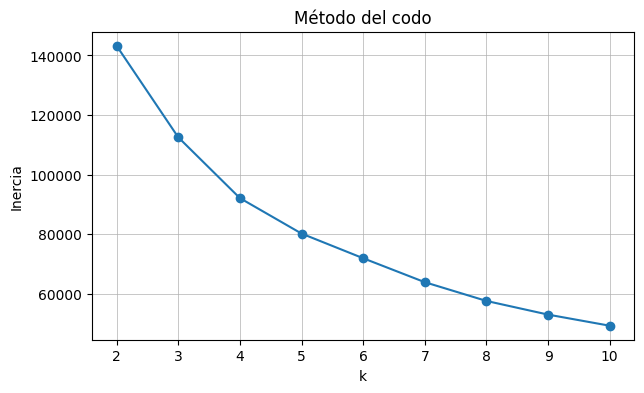

k seleccionado: 4


In [9]:
# Esta celda calcula la inercia de K-Means para k=2..10 (método del codo).
k_range = range(2, 11)
inercias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inercias, marker="o")
plt.title("Método del codo")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.xticks(list(k_range))
plt.grid(True, lw=0.5)
plt.show()

k_opt = 4
print(f"k seleccionado: {k_opt}")

### Aplicacion del modelo (5D escalados, no sobre PCA)


In [10]:
# El ajuste va sobre las 5 dimensiones estandarizadas, NO sobre las coordenadas
# PCA: la proyección 2D pierde ~22% de la varianza y distorsionaría las distancias.
k_opt = 4
km = KMeans(n_clusters=k_opt, random_state=random_state, n_init=10)
etiquetas = km.fit_predict(X_scaled)

# Solo para visualizar; no interviene en el ajuste
coords_2d = PCA(n_components=2, random_state=random_state).fit_transform(X_scaled)

print(f"Clusters encontrados: k={k_opt}")

Clusters encontrados: k=4


### Visualizacion

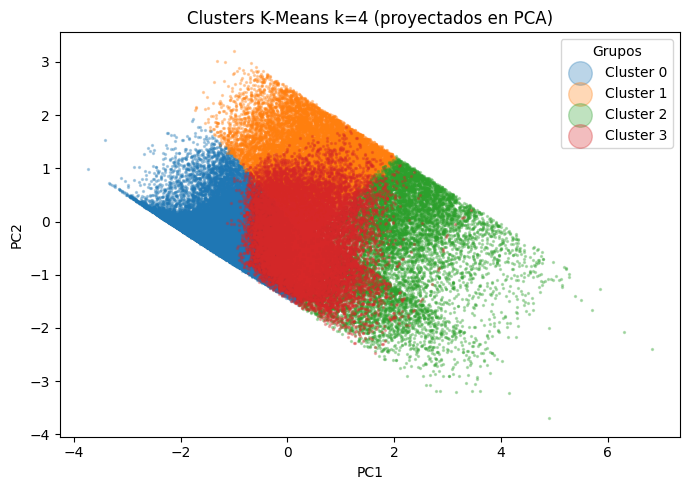

In [11]:
# Esta celda dibuja los clusters de K-Means proyectados sobre PC1/PC2.
plt.figure(figsize=(7, 5))

# Un scatter por cluster para que aparezca en la leyenda
for c in sorted(np.unique(etiquetas)):
    mask = etiquetas == c
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                label=f"Cluster {c}", s=2, alpha=0.3)

plt.title(f"Clusters K-Means k={k_opt} (proyectados en PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=12, title="Grupos", loc="best")
plt.tight_layout()
plt.savefig("../results/figures/kmeans_clusters.png", dpi=110)  # figura del paper
plt.show()

### Distribucion de clusters

In [12]:
# Esta celda calcula la media de cada feature por cluster, para interpretarlos.
X_con_cluster = X.copy()
X_con_cluster["Cluster"] = etiquetas

print("Medias por cluster (escala original):")
print(X_con_cluster.groupby("Cluster")[features].mean().round(4))

Medias por cluster (escala original):


         CA DistanceNominal (au)  V infinity(km/s)   H(mag)
Cluster                                                    
0                         0.0613            9.1886  25.9221
1                         0.3748           12.3848  25.0580
2                         0.2932           23.2700  21.0344
3                         0.1729           10.9541  21.7033


### Interpretaciones

K-Means se ajusta sobre las 3 dimensiones estandarizadas (el PCA solo proyecta
para visualizar). El **k = 4 se fijó con el método del codo** sobre la inercia
(criterio visual; la celda del codo es exploratoria). Medias por cluster
(escala original):

- **Cluster 0** — muy cercanos (dist≈0.06 au), lentos (v≈9.2 km/s) y pequeños
  (H≈25.9).
- **Cluster 1** — lejanos (dist≈0.37 au), algo más rápidos (v≈12.4 km/s) y
  pequeños (H≈25.1).
- **Cluster 2** — lejanos (dist≈0.29 au) pero muy rápidos (v≈23.3 km/s) y
  **grandes** (H≈21.0): el único grupo compatible con el corte de tamaño de la
  definición PHA (H ≤ 22).
- **Cluster 3** — cercanos (dist≈0.17 au), lentos (v≈11.0 km/s) y grandes
  (H≈21.7): también compatible con H ≤ 22, y más próximos que el Cluster 2.

Los dos clusters "grandes" (2 y 3) se separan por velocidad y distancia, no por
tamaño — consistente con que el tamaño estructura la varianza principal pero la
cinemática aporta una segunda distinción real, coherente con la clasificación
supervisada de más abajo.

## t-SNE (t-distributed Stochastic Neighbor Embedding)

Técnica de reducción de dimensionalidad no lineal, diseñada principalmente para
visualizar datos de alta dimensión en 2D o 3D.

Su principio central es preservar las relaciones locales: si dos puntos están
próximos en el espacio original, deben seguir próximos en el mapa. Las distancias
*entre* grupos y los tamaños relativos de los grupos **no son interpretables**.

Aquí t-SNE cumple un papel puramente ilustrativo: no sustenta ninguna conclusión
del trabajo. Por eso se usa un único embedding con hiperparámetros estándar sobre
una submuestra con semilla fija, en vez de la búsqueda con Optuna de versiones
anteriores (inviable sobre 340k eventos y sin efecto sobre los resultados).

In [13]:
# Esta celda importa las librerías del bloque t-SNE.
import numpy as np
import pandas as pd
import optuna
from openTSNE import TSNE
from sklearn.manifold import trustworthiness

### Embedding sobre submuestra

Un único ajuste con `perplexity = 50` sobre una submuestra aleatoria de 8 000
eventos (semilla fija; el tamaño lo impone la memoria O(n²) de *trustworthiness*). Se reporta la *trustworthiness* como control de calidad
del mapa: mide qué fracción de los vecindarios locales se conserva.

In [14]:
# La busqueda con Optuna (200 trials) es inviable sobre 340k eventos. Se usa un
# unico embedding con hiperparametros estandar sobre una submuestra aleatoria
# con semilla fija. El tamano lo fija trustworthiness, que es O(n^2) en memoria:
# 8k puntos -> 0.5 GB y metrica exacta; 30k exigirian 6.7 GB.
# t-SNE NO sustenta ninguna conclusion del paper: solo ilustra la estructura.
N_SUB = 8000
PERPLEXITY = 50

rng = np.random.default_rng(random_state)
idx_sub = rng.choice(len(X_scaled), size=min(N_SUB, len(X_scaled)), replace=False)
X_sub = X_scaled[idx_sub]

tsne = TSNE(perplexity=PERPLEXITY, n_iter=1000, random_state=random_state,
            verbose=False, n_jobs=1)
embedding = tsne.fit(X_sub)

trust = trustworthiness(X_sub, np.asarray(embedding), n_neighbors=15)
print(f"t-SNE sobre {len(X_sub):,} eventos (perplexity={PERPLEXITY})")
print(f"  trustworthiness = {trust:.4f}")

t-SNE sobre 8,000 eventos (perplexity=50)
  trustworthiness = 0.9983


### Visualización del embedding

Color por magnitud absoluta `H` (escala invertida: más oscuro = objeto mayor).

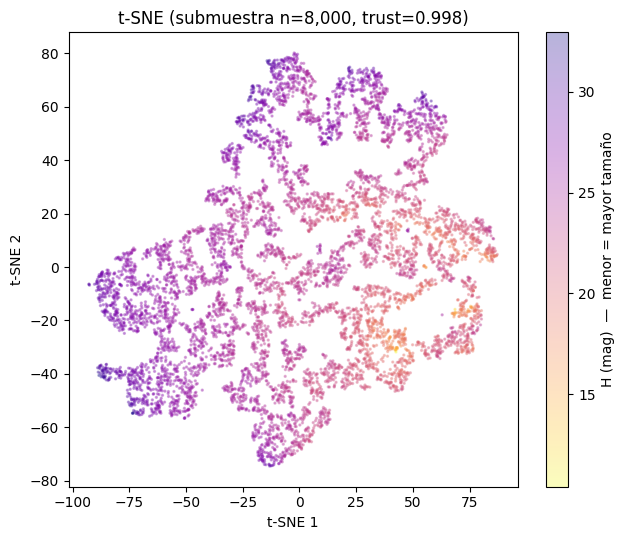

In [15]:
# Esta celda dibuja el embedding t-SNE coloreado por tamaño (H).
plt.figure(figsize=(6.5, 5.5))
plt.scatter(np.asarray(embedding)[:, 0], np.asarray(embedding)[:, 1],
            c=X["H(mag)"].values[idx_sub], cmap="plasma_r", s=2, alpha=0.3)
plt.colorbar(label="H (mag)  —  menor = mayor tamaño")
plt.title(f"t-SNE (submuestra n={len(X_sub):,}, trust={trust:.3f})")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig("../results/figures/tsne_quick.png", dpi=110)  # figura del paper
plt.show()

# Sustitución de medida y función de selección

El análisis previo (PCA / K-Means / t-SNE) es **exploratorio**. Aquí abordamos la
pregunta central del trabajo:

> **¿Puede la distancia mínima observada en las aproximaciones cercanas sustituir
> al MOID orbital que define formalmente a un asteroide potencialmente peligroso
> (PHA), y cómo distorsiona esa sustitución la función de selección observacional
> de 126 años de catálogo?**

Es deliberadamente una pregunta de **medida**, no de predicción. PHA no es un
fenómeno físico sino una definición administrativa: un objeto es PHA si
`MOID ≤ 0.05 au` **y** `H ≤ 22`[^1]. Cualquier clasificador alimentado con proxies de
esas dos cantidades no *predice* nada — reconstruye una definición. Lo hacemos
explícito y medimos, en su lugar, dos cosas que sí son empíricas:

1. **El error de sustitución**: cuánto se pierde al reemplazar el MOID (calculado
   a partir de los elementos orbitales) por la distancia efectivamente observada.
2. **La distorsión por selección**: cómo depende ese error de cuánto se ha
   observado cada objeto, y cómo cambia el rendimiento bajo el desplazamiento de
   prevalencia real entre épocas de descubrimiento.

El aprendizaje supervisado se usa aquí como **instrumento de medida**, no como
contribución: sirve para cuantificar cuánta información aporta cada bloque de
variables, y su desempeño casi perfecto es un síntoma de circularidad que
documentamos, no un resultado que reivindiquemos.

[^1]: Criterio oficial de Potentially Hazardous Asteroid. Fuente: [CNEOS FAQ](https://cneos.jpl.nasa.gov/faq/) (JPL/NASA, Center for Near Earth Object Studies).

## Agregación a nivel objeto

La peligrosidad es propiedad del **objeto**. Agregamos los eventos por `Object`,
resumiendo cinemática observada e historia de observación.

In [16]:
# Esta celda agrega los eventos por objeto: un registro por asteroide con sus
# estadísticos de distancia, velocidad, tamaño y exposición observacional.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Incertidumbre de la aproximacion: dist_min es la cota 3-sigma, no una
# distancia fisica. Su separacion respecto a la nominal mide calidad orbital,
# asi que entra como variable propia en vez de fundirse con la proximidad.
df["dist_unc"] = df["CA DistanceNominal (au)"] - df["CA DistanceMinimum (au)"]  # ancho del intervalo 3σ (nominal − mínima): mide incertidumbre orbital, no proximidad

# n_appro mide exposición observacional, no física; first_obs_year y data_arc
# son metadatos de SELECCIÓN y nunca entran como features.
# Se descartan los objetos sin match en la SBDB (sin etiqueta pha).
obj = df.groupby("Object").agg(
    distnom_min=("CA DistanceNominal (au)", "min"),
    distmin_min=("CA DistanceMinimum (au)", "min"),
    dist_unc_med=("dist_unc", "median"),
    vrel_max=("V relative(km/s)", "max"),
    vinf_med=("V infinity(km/s)", "median"),
    vinf_max=("V infinity(km/s)", "max"),
    H_obs=("H(mag)", "min"),
    diam_max=("Diameter(km)", "max"),
    n_appro=("Object", "size"),
    first_obs_year=("first_obs_year", "max"),
    data_arc=("data_arc(d)", "max"),
    pha=("PHA_official", "max"),
).reset_index().dropna(subset=["pha"])
obj["pha"] = obj["pha"].astype(int)
print(f"Objetos: {len(obj):,} | PHA: {obj['pha'].sum():,} ({100*obj['pha'].mean():.1f}%)  "
      f"(1 PHA por cada {int((obj['pha']==0).sum()/obj['pha'].sum())} no-PHA)")

Objetos: 37,405 | PHA: 2,263 (6.0%)  (1 PHA por cada 15 no-PHA)


## Colinealidad y poda de features

Varias features son redundantes: el diámetro se imputa desde `H` (dependientes) y las
tres velocidades son casi idénticas. Lo verificamos y definimos conjuntos **podados**.

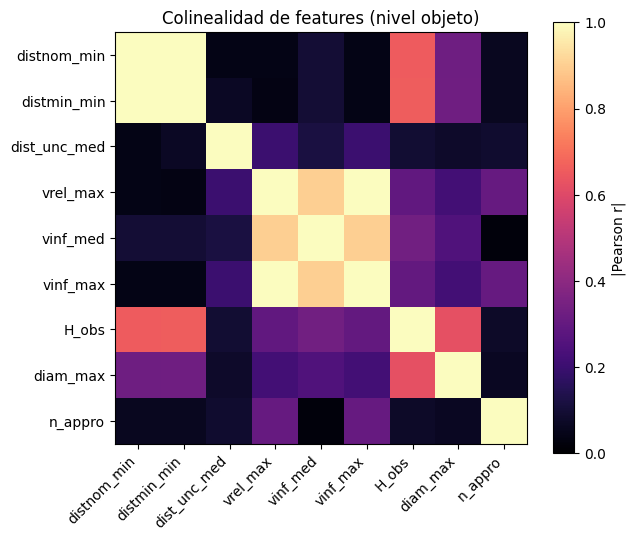

Pares |corr|>0.9:
  distnom_min ~ distmin_min: 0.998
  vrel_max ~ vinf_med: 0.901
  vrel_max ~ vinf_max: 1.000
  vinf_med ~ vinf_max: 0.900


In [17]:
# Esta celda mide la colinealidad entre las features candidatas y define los
# tres conjuntos podados (kin+size, kin-only, size-only) que se comparan después.
cand = ["distnom_min","distmin_min","dist_unc_med","vrel_max","vinf_med","vinf_max",
        "H_obs","diam_max","n_appro"]
Cmat = obj[cand].corr().abs()
plt.figure(figsize=(6.5,5.5))
plt.imshow(Cmat, cmap="magma", vmin=0, vmax=1); plt.colorbar(label="|Pearson r|")
plt.xticks(range(len(cand)), cand, rotation=45, ha="right"); plt.yticks(range(len(cand)), cand)
plt.title("Colinealidad de features (nivel objeto)")
plt.tight_layout(); plt.savefig("../results/figures/clf_collinearity.png", dpi=110); plt.show()
print("Pares |corr|>0.9:")
for i,a in enumerate(cand):
    for b in cand[i+1:]:
        if Cmat.loc[a,b]>0.9: print(f"  {a} ~ {b}: {Cmat.loc[a,b]:.3f}")

# Se conserva la distancia NOMINAL (distmin_min es una cota 3-sigma que mezcla
# proximidad con incertidumbre orbital), una sola velocidad y un solo indicador
# de tamaño (H_obs; diam_max se descarta por estar imputado desde H).
FEAT = {
    "kin+size": ["distnom_min","vinf_max","H_obs","n_appro"],
    "kin-only": ["distnom_min","vinf_max","n_appro"],
    "size-only":["H_obs"],
}

## Clasificación supervisada con validación cruzada

Repeated Stratified K-Fold (5×3). Métrica principal **F2** (prioriza recall) más
**PR-AUC** y **ROC-AUC**; reportamos media ± desv. estándar. *Accuracy se omite.*

In [18]:
# Esta celda entrena LogReg/RandomForest/XGBoost con CV 5x3 repetida sobre cada
# conjunto de features, y tabula F2 / PR-AUC / ROC-AUC.
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import fbeta_score, make_scorer
from xgboost import XGBClassifier

random_state = 20  # misma semilla global del proyecto
y = obj["pha"].values
# Desbalance ~13:1 → scale_pos_weight para XGBoost (los demás usan class_weight)
spw = (y==0).sum()/max((y==1).sum(),1)  # nº negativos / nº positivos: XGBoost pondera cada positivo por este factor para compensar el desbalance

def make_models():
    return {
        "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,
                     class_weight="balanced", random_state=random_state)),
        "RandForest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                     random_state=random_state, n_jobs=1),
        "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                     random_state=random_state, eval_metric="logloss", scale_pos_weight=spw, n_jobs=1),
    }

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=random_state)
scoring = {"F2": make_scorer(fbeta_score, beta=2), "PR-AUC":"average_precision", "ROC-AUC":"roc_auc"}
rows=[]
for fset, cols in FEAT.items():
    # Imputación por mediana de los pocos NaN residuales en features observadas
    X = obj[cols].fillna(obj[cols].median()).values
    for mname, m in make_models().items():
        sc = cross_validate(m, X, y, cv=cv, scoring=scoring, n_jobs=1)
        rows.append({"features":fset, "model":mname,
                     "F2":sc['test_F2'].mean(), "F2_std":sc['test_F2'].std(),
                     "PR-AUC":sc['test_PR-AUC'].mean(), "ROC-AUC":sc['test_ROC-AUC'].mean()})
tabla = pd.DataFrame(rows)
print(tabla.round(3).to_string(index=False))

 features      model    F2  F2_std  PR-AUC  ROC-AUC
 kin+size     LogReg 0.675   0.006   0.403    0.945
 kin+size RandForest 0.520   0.015   0.723    0.968
 kin+size    XGBoost 0.713   0.006   0.726    0.970
 kin-only     LogReg 0.348   0.011   0.159    0.752
 kin-only RandForest 0.037   0.009   0.142    0.738
 kin-only    XGBoost 0.382   0.009   0.191    0.785
size-only     LogReg 0.655   0.005   0.287    0.916
size-only RandForest 0.615   0.009   0.280    0.906
size-only    XGBoost 0.653   0.004   0.285    0.917


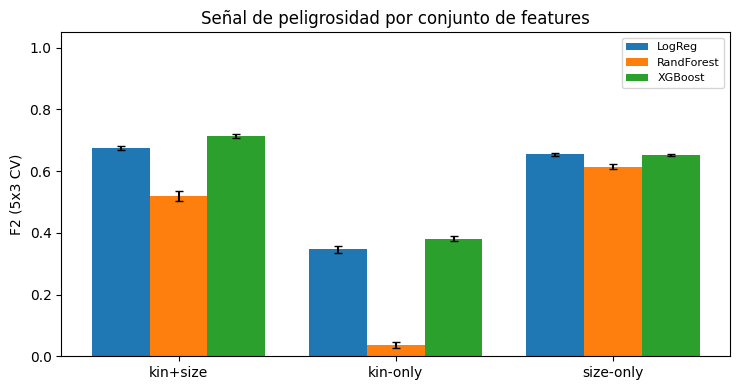

In [19]:
# Esta celda dibuja el F2 de la tabla anterior, por conjunto de features y modelo.
sets=list(FEAT); mods=sorted(tabla['model'].unique()); w=0.8/len(mods)  # ancho de barra: reparte 0.8 del espacio de cada tick entre los modelos, para que quede hueco entre grupos
plt.figure(figsize=(7.5,4))
for j,mod in enumerate(mods):
    sub=tabla[tabla.model==mod].set_index('features').reindex(sets)
    plt.bar([i+j*w for i in range(len(sets))], sub['F2'], w, yerr=sub['F2_std'], capsize=3, label=mod)
plt.xticks([i+0.4-w/2 for i in range(len(sets))], sets); plt.ylim(0,1.05)  # centra la etiqueta del feature-set bajo su grupo de barras (offset = mitad del grupo menos media barra)
plt.ylabel("F2 (5x3 CV)"); plt.legend(fontsize=8); plt.title("Señal de peligrosidad por conjunto de features")
plt.tight_layout(); plt.savefig("../results/figures/clf_f2_por_features.png", dpi=110); plt.show()

## Circularidad / *leakage*

PHA se **define** por `MOID≤0.05 au` y `H≤22`. Con el dataset corregido, la
regla de dos umbrales sobre lo observado **ya no iguala al ML**: obtiene
F2=0.343, muy por debajo del F2=0.713 de XGBoost sobre `kin+size`. La censura
del dataset anterior (que forzaba `distmin_min≤0.05` en el 100% de los objetos)
inflaba artificialmente esa regla hasta igualar al modelo; al corregirla, la
brecha entre "regla trivial" y "modelo entrenado" se hace evidente — hay señal
real que el ML captura y la regla de umbrales no.

Sigue habiendo un techo de precisión ligado a la definición (`H` es una de las
dos variables que la constituyen), pero ya no es un ejercicio circular vacío:
`kin+size` (F2=0.713) supera tanto a `size-only` (F2=0.653) como a `kin-only`
(F2=0.382), así que la cinemática **sí añade información** sobre el tamaño solo.

In [20]:
# Esta celda calcula el baseline de regla de umbral (sin ningún modelo) para
# contrastarlo con los clasificadores entrenados arriba.
from sklearn.metrics import fbeta_score, precision_score, recall_score

regla = ((obj["distmin_min"]<=0.05)&(obj["H_obs"]<=22)).astype(int).values  # bool → 0/1: fbeta_score/precision_score/recall_score esperan enteros, no booleanos
print(f"Baseline regla de umbral:  F2={fbeta_score(y,regla,beta=2):.3f}  "
      f"prec={precision_score(y,regla):.3f}  rec={recall_score(y,regla):.3f}")

Baseline regla de umbral:  F2=0.343  prec=0.985  rec=0.295


## Curvas PR / ROC y umbral de decisión

Probabilidades fuera de fold (StratifiedKFold). Reportamos el umbral que maximiza F2,
en vez de asumir 0.5.

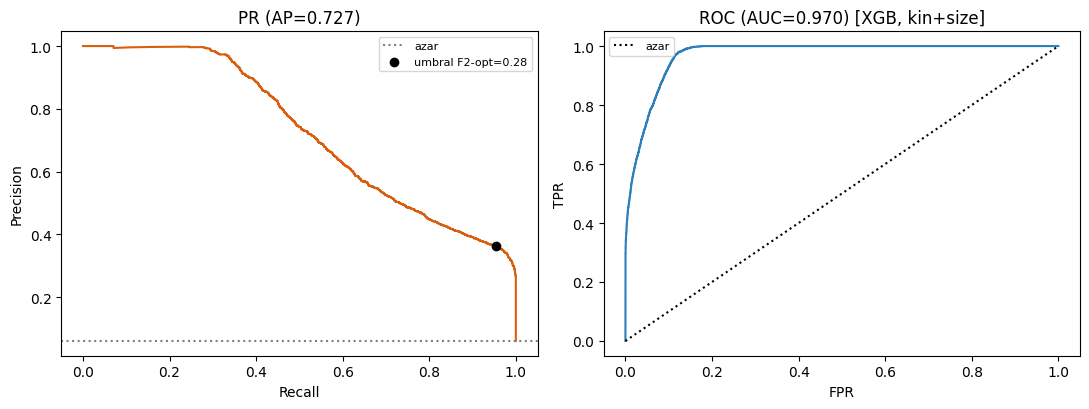

Umbral F2-óptimo: 0.284  (vs 0.5 por defecto)


In [21]:
# Esta celda saca probabilidades fuera de fold con XGBoost (kin+size) y dibuja
# las curvas PR y ROC, marcando el umbral que maximiza F2.
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score

cols=FEAT["kin+size"]; X=obj[cols].fillna(obj[cols].median()).values
skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
proba=cross_val_predict(make_models()["XGBoost"], X, y, cv=skf, method="predict_proba", n_jobs=1)[:,1]

prec,rec,thr=precision_recall_curve(y,proba); f2c=(5*prec*rec)/(4*prec+rec+1e-12)  # F2=(1+2²)·prec·rec/(2²·prec+rec)=5·prec·rec/(4·prec+rec); +1e-12 evita 0/0 cuando prec=rec=0
bi=int(np.nanargmax(f2c[:-1])); fpr,tpr,_=roc_curve(y,proba)  # descarta el último punto de la curva (recall=0, sin umbral asociado) antes de buscar el máximo

plt.figure(figsize=(11,4.2))

plt.subplot(1,2,1)
plt.plot(rec,prec,color="#d95f0e"); plt.axhline(y.mean(),color="gray",ls=":",label="azar")
plt.scatter(rec[bi],prec[bi],color="k",zorder=5,label=f"umbral F2-opt={thr[bi]:.2f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"PR (AP={average_precision_score(y,proba):.3f})"); plt.legend(fontsize=8)

plt.subplot(1,2,2)
plt.plot(fpr,tpr,color="#2c7fb8"); plt.plot([0,1],[0,1],"k:",label="azar")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title(f"ROC (AUC={auc(fpr,tpr):.3f}) [XGB, kin+size]"); plt.legend(fontsize=8)

plt.tight_layout(); plt.savefig("../results/figures/clf_pr_roc.png", dpi=110); plt.show()
print(f"Umbral F2-óptimo: {thr[bi]:.3f}  (vs 0.5 por defecto)")

## Importancia de variables (SHAP)

`H_obs` sigue siendo la variable individual más informativa (coherente con que
es una de las dos que definen PHA), pero con el dataset corregido `kin+size`
supera a `size-only` en la tabla de CV (F2 0.713 vs 0.653): las variables
cinemáticas (`distnom_min`, `n_appro`) aportan una contribución medible, que el
gráfico de importancias y el *beeswarm* de SHAP desglosan a continuación.

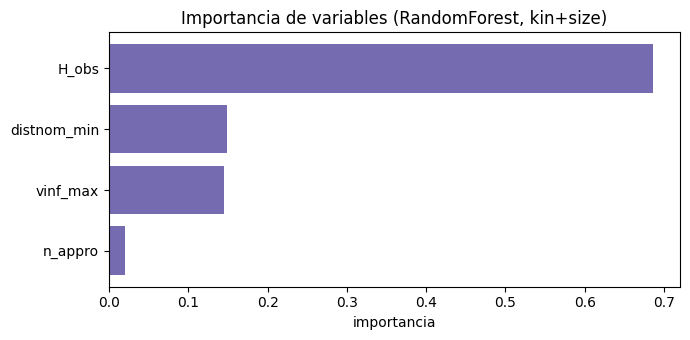

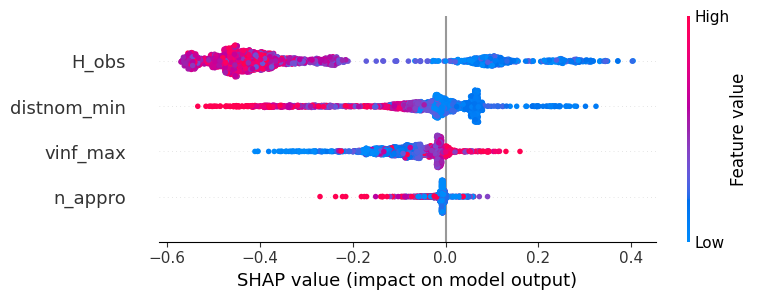

In [22]:
# Esta celda entrena un RandomForest sobre kin+size y calcula su importancia de
# variables (barras) y sus valores SHAP (beeswarm) sobre una submuestra.
import shap
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=random_state, n_jobs=1).fit(X,y)
imp=pd.Series(rf.feature_importances_, index=cols).sort_values()
plt.figure(figsize=(7,3.5)); plt.barh(imp.index, imp.values, color="#756bb1")
plt.title("Importancia de variables (RandomForest, kin+size)"); plt.xlabel("importancia")
plt.tight_layout(); plt.savefig("../results/figures/clf_importancia.png", dpi=110); plt.show()

samp=pd.DataFrame(X, columns=cols).sample(min(2000,len(X)), random_state=random_state)  # tope de 2000 filas: SHAP es O(n) por muestra y con miles de puntos alcanza para el resumen visual
sv=np.array(shap.TreeExplainer(rf).shap_values(samp))
if sv.ndim==3: sv = sv[...,1] if sv.shape[-1]==2 else sv[1]
plt.figure(); shap.summary_plot(sv, samp, show=False)
plt.tight_layout(); plt.savefig("../results/figures/clf_shap.png", dpi=110, bbox_inches="tight"); plt.show()

## Selección observacional (por fecha real de descubrimiento)

Usamos `first_obs_year` (primera observación astrométrica, SBDB), no el año del
primer evento de aproximación. La prevalencia de PHA cae monótonamente con la
época de descubrimiento, y el **arco orbital** (`data_arc`) — proxy de
caracterización — la acompaña: el confundidor es explícito.

Además del desplazamiento de prevalencia, hacemos el **hold-out temporal real**:
entrenamos con los objetos descubiertos antes de 2015 y evaluamos sobre los
descubiertos después (el escenario operativo de un sondeo), con imputación
ajustada solo en el train para evitar fugas.

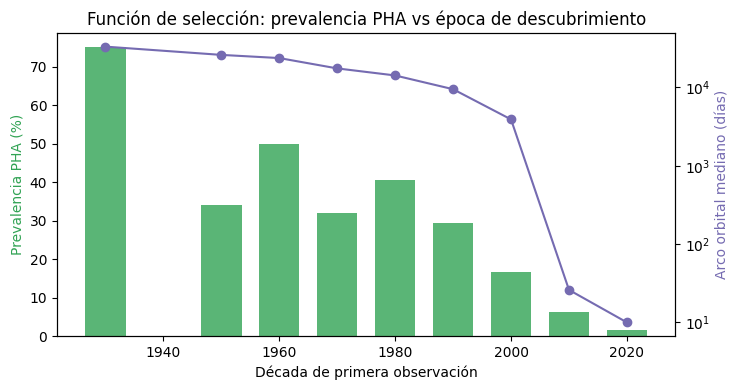

Hold-out temporal first_obs<2015: train=10880 (PHA 14.6%) -> test=26525 (PHA 2.6%)
corr(data_arc, PHA) = 0.351


XGBoost kin+size entrenado <2015 → evaluado ≥2015:
  F2=0.611  prec=0.388  rec=0.714  PR-AUC=0.611
  (referencia: F2=0.713 en CV aleatoria — la caída mide el coste del desplazamiento de prevalencia 14.6% → 2.6%)


In [23]:
o=obj.dropna(subset=["first_obs_year"]).copy(); o["dec"]=(o["first_obs_year"]//10*10).astype(int)  # redondea el año a la década: división entera por 10 y luego ×10 (1987 → 1980)
g=o.groupby("dec").agg(n=("pha","size"),prev=("pha","mean"),arc=("data_arc","median")); g=g[g["n"]>=5]

plt.figure(figsize=(7.5,4))
plt.bar(g.index, g["prev"]*100, width=7, color="#31a354", alpha=0.8)  # fracción → porcentaje para el eje Y; width=7 años para que las barras casi se toquen entre décadas
plt.ylabel("Prevalencia PHA (%)", color="#31a354"); plt.xlabel("Década de primera observación")
plt.title("Función de selección: prevalencia PHA vs época de descubrimiento")

plt.twinx()  # segundo eje Y para el arco orbital
plt.plot(g.index, g["arc"], "o-", color="#756bb1"); plt.yscale("symlog")
plt.ylabel("Arco orbital mediano (días)", color="#756bb1")

plt.tight_layout(); plt.savefig("../results/figures/selection_temporal.png", dpi=110); plt.show()

cut=2015; tr=o[o.first_obs_year<cut]; te=o[o.first_obs_year>=cut]
print(f"Hold-out temporal first_obs<{cut}: train={len(tr)} (PHA {100*tr['pha'].mean():.1f}%) "
      f"-> test={len(te)} (PHA {100*te['pha'].mean():.1f}%)")
print(f"corr(data_arc, PHA) = {o['data_arc'].corr(o['pha']):.3f}")

from sklearn.metrics import average_precision_score, precision_score, recall_score
cols_t = FEAT["kin+size"]
med_tr = tr[cols_t].median()  # medianas del TRAIN: sin fuga del futuro al pasado
Xtr, Xte = tr[cols_t].fillna(med_tr).values, te[cols_t].fillna(med_tr).values
ytr, yte = tr["pha"].values, te["pha"].values
spw_t = (ytr==0).sum()/max((ytr==1).sum(),1)  # desbalance del TRAIN, no global
clf_t = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                      random_state=random_state, eval_metric="logloss",
                      scale_pos_weight=spw_t, n_jobs=1).fit(Xtr, ytr)
proba_t = clf_t.predict_proba(Xte)[:,1]
pred_t  = (proba_t >= 0.5).astype(int)  # umbral 0.5 fijo a propósito aquí: se compara contra el default, no contra el F2-óptimo de la celda anterior
f2_cv = tabla[(tabla.features=="kin+size")&(tabla.model=="XGBoost")]["F2"].iloc[0]
print(f"XGBoost kin+size entrenado <{cut} → evaluado ≥{cut}:")
print(f"  F2={fbeta_score(yte, pred_t, beta=2):.3f}  "
      f"prec={precision_score(yte, pred_t):.3f}  rec={recall_score(yte, pred_t):.3f}  "
      f"PR-AUC={average_precision_score(yte, proba_t):.3f}")
print(f"  (referencia: F2={f2_cv:.3f} en CV aleatoria — la caída mide el coste "
      f"del desplazamiento de prevalencia {100*tr['pha'].mean():.1f}% → {100*te['pha'].mean():.1f}%)")

## Sesgo de muestreo

El catálogo está condicionado a objetos con aproximaciones cercanas registradas.
El sesgo hay que leerlo en **cada condición de la definición por separado**: la
prevalencia PHA es el producto de ambas y los dos efectos pueden cancelarse,
dando la falsa impresión de que no hay sesgo.

            población     n  PHA (%)  MOID<=0.05 (%)  H<=22 (%)
todos los NEOs (SBDB) 42318      6.1            54.1       27.6
   en el catálogo CAD 37405      6.0            59.4       21.4
   NEOs no capturados  4913      6.2            12.5       75.2


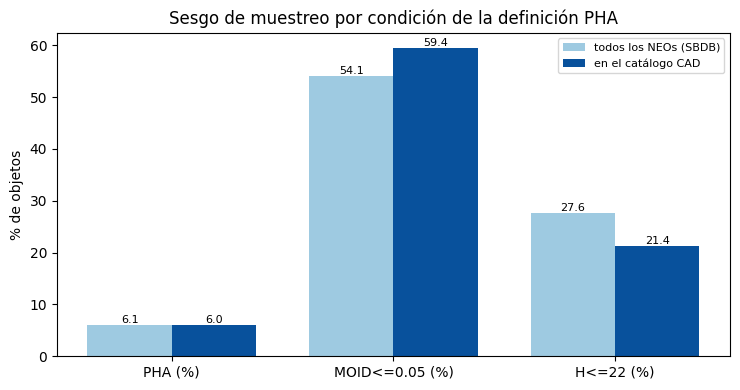


La prevalencia PHA apenas se mueve porque los dos sesgos se oponen:
  MOID<=0.05 se enriquece y H<=22 se empobrece. Leer solo la
  prevalencia conjunta llevaría a concluir 'sin sesgo'.


In [24]:
# Esta celda compara la prevalencia PHA y las dos condiciones de su definición
# (MOID, H) entre todos los NEOs de la SBDB y los que sí quedaron en el catálogo.
ruta_sb = os.path.join("..","data","sbdb_neo.csv")
if os.path.exists(ruta_sb):
    sb = pd.read_csv(ruta_sb)
    for _c in ["moid","H"]:
        sb[_c] = pd.to_numeric(sb[_c], errors="coerce")
    sb["pha01"] = sb["pha"].map({"Y":1,"N":0})
    sb["en_cat"] = sb["pdes"].astype(str).isin(set(obj["Object"].astype(str)))

    # El sesgo hay que leerlo en CADA condicion de la definicion por separado:
    # la prevalencia PHA es su producto y los dos efectos pueden cancelarse.
    filas = []
    for lab, sub in [("todos los NEOs (SBDB)", sb),
                     ("en el catálogo CAD", sb[sb.en_cat]),
                     ("NEOs no capturados", sb[~sb.en_cat])]:
        v = sub.dropna(subset=["moid"])
        filas.append({"población": lab, "n": len(sub),
                      "PHA (%)": 100*sub.pha01.mean(),  # fracción → porcentaje, igual que las dos columnas siguientes
                      "MOID<=0.05 (%)": 100*(v.moid<=0.05).mean(),
                      "H<=22 (%)": 100*(sub.H<=22).mean()})
    tabla_sesgo = pd.DataFrame(filas)
    print(tabla_sesgo.round(1).to_string(index=False))

    ejes = ["PHA (%)","MOID<=0.05 (%)","H<=22 (%)"]
    pobl = ["todos los NEOs (SBDB)","en el catálogo CAD"]
    w = 0.38  # ancho de cada barra: dos poblaciones por eje, dejando margen entre ejes
    plt.figure(figsize=(7.5,4))
    for j,p in enumerate(pobl):
        vals = tabla_sesgo.set_index("población").loc[p, ejes].values.astype(float)
        plt.bar([i+j*w for i in range(len(ejes))], vals, w,
                label=p, color=["#9ecae1","#08519c"][j])
        for i,v in enumerate(vals):
            plt.text(i+j*w, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    plt.xticks([i+w/2 for i in range(len(ejes))], ejes)
    plt.ylabel("% de objetos"); plt.legend(fontsize=8)
    plt.title("Sesgo de muestreo por condición de la definición PHA")
    plt.tight_layout(); plt.savefig("../results/figures/selection_sampling.png", dpi=110); plt.show()

    print("\nLa prevalencia PHA apenas se mueve porque los dos sesgos se oponen:")
    print("  MOID<=0.05 se enriquece y H<=22 se empobrece. Leer solo la")
    print("  prevalencia conjunta llevaría a concluir 'sin sesgo'.")

## Resultado central: ¿sustituye la distancia observada al MOID?

La distancia mínima observada es un sustituto de **alta precisión y bajo recall**
del MOID orbital. La razón es geométrica: la distancia de un encuentro real es
siempre ≥ el MOID, y solo coincide con él si el objeto es capturado justo en la
configuración orbital más desfavorable — algo que rara vez ocurre con unas pocas
aproximaciones observadas.

La consecuencia práctica es que el recall del proxy **no mide una propiedad del
asteroide, sino cuánto se le ha observado**: crece monótonamente con el número de
aproximaciones registradas. Cualquier estudio que use la distancia observada como
sustituto del MOID hereda ese sesgo.

Sustitución del MOID por la distancia observada:
  r = 0.869   precisión = 0.985   recall = 0.295
  entre PHA reales: dist. observada mediana = 0.0789 au vs MOID mediano = 0.0232 au  (3.8x)


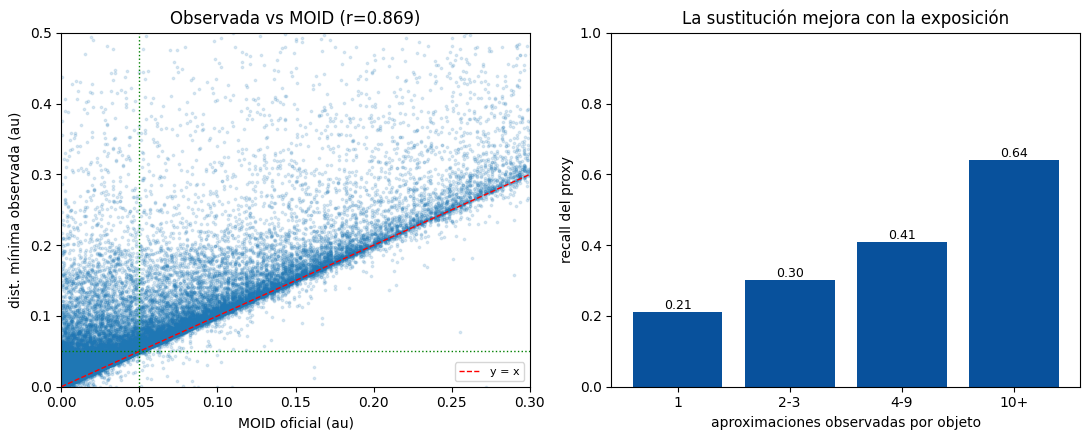

In [25]:
from sklearn.metrics import precision_score, recall_score

# Proxy evaluado sobre lo OBSERVADO (obj ya excluye eventos integrados)
po = obj.join(df.drop_duplicates("Object").set_index("Object")["MOID (au)"],
              on="Object").dropna(subset=["MOID (au)"])
proxy = ((po["H_obs"]<=22) & (po["distmin_min"]<=0.05)).astype(int)
corr = po["distmin_min"].corr(po["MOID (au)"])
prec = precision_score(po["pha"], proxy); rec = recall_score(po["pha"], proxy)
print(f"Sustitución del MOID por la distancia observada:")
print(f"  r = {corr:.3f}   precisión = {prec:.3f}   recall = {rec:.3f}")

# Por que falla: la aproximacion observada rara vez alcanza el minimo orbital
pha_si = po[po["pha"]==1]
razon = (pha_si["distmin_min"]/pha_si["MOID (au)"].replace(0,np.nan)).median()  # cociente obs/MOID; replace(0,NaN) evita división por cero en objetos con MOID≈0
print(f"  entre PHA reales: dist. observada mediana = {pha_si['distmin_min'].median():.4f} au "
      f"vs MOID mediano = {pha_si['MOID (au)'].median():.4f} au  ({razon:.1f}x)")

# El recall depende de la EXPOSICION observacional, no de la fisica del objeto
tramos = [(1,1),(2,3),(4,9),(10,10**6)]  # cortes de exposición observacional: 1, 2–3, 4–9, 10+ aproximaciones por objeto
recs, etiq = [], []
for lo,hi in tramos:
    s = (po["n_appro"]>=lo)&(po["n_appro"]<=hi)
    if s.sum()>50 and po.loc[s,"pha"].sum()>0:
        recs.append(recall_score(po.loc[s,"pha"], proxy[s]))
        etiq.append(f"{lo}" if lo==hi else (f"{lo}+" if hi>10**5 else f"{lo}-{hi}"))

fig = plt.figure(figsize=(11,4.5))

plt.subplot(1,2,1)
plt.scatter(po["MOID (au)"], po["distmin_min"], s=3, alpha=0.15)
plt.plot([0,0.5],[0,0.5],"r--",lw=1,label="y = x")
plt.axvline(0.05,color="g",ls=":",lw=1); plt.axhline(0.05,color="g",ls=":",lw=1)
plt.xlim(0,0.3); plt.ylim(0,0.5)
plt.xlabel("MOID oficial (au)"); plt.ylabel("dist. mínima observada (au)")
plt.title(f"Observada vs MOID (r={corr:.3f})"); plt.legend(fontsize=8)

plt.subplot(1,2,2)
plt.bar(etiq, recs, color="#08519c")
for i,v in enumerate(recs): plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.ylim(0,1); plt.xlabel("aproximaciones observadas por objeto")
plt.ylabel("recall del proxy"); plt.title("La sustitución mejora con la exposición")

plt.tight_layout(); plt.savefig("../results/figures/proxy_vs_moid.png", dpi=110); plt.show()

## Conclusiones

1. **La clasificación ya no es trivial ni circular.** La regla de dos umbrales
   sobre lo observado obtiene F2=0.343, muy por debajo de XGBoost (F2=0.713,
   `kin+size`). La versión censurada del dataset (que restringía la consulta a
   `dist ≤ 0.05 au`, el default de la CAD API) forzaba artificialmente esa
   igualdad; al corregirla desaparece.
2. **La cinemática aporta señal real, no solo el tamaño.** `kin+size` (F2=0.713)
   supera a `size-only` (F2=0.653) y ambos superan ampliamente a `kin-only`
   (F2=0.382): el tamaño es el predictor individual más fuerte (coherente con
   ser una de las dos variables que definen PHA), pero la cinemática observada
   añade información medible por encima de él.
3. **El catálogo es un registro de detección**, condicionado por selección
   observacional. Comparado con el total de NEOs de la SBDB, la prevalencia PHA
   apenas se mueve (6.1% → 6.0%) porque dos sesgos opuestos casi se cancelan:
   el catálogo enriquece la condición MOID≤0.05 (54.1%→59.4%) y empobrece la
   condición H≤22 (27.6%→21.4%). Leer solo la prevalencia agregada ocultaría
   ambos efectos.
4. **El hold-out temporal real cuantifica el coste de la selección por época.**
   XGBoost (`kin+size`) entrenado con objetos descubiertos antes de 2015
   (prevalencia 14.6%) y evaluado sobre los posteriores (2.6%) cae de F2=0.713
   (CV aleatoria) a F2=0.611, con precisión 0.388 y recall 0.714: el
   desplazamiento de prevalencia degrada sobre todo la precisión.
5. **La distancia observada aproxima el MOID pero con recall bajo (r=0.869,
   precisión=0.985, recall=0.295):** entre los PHA reales, la distancia
   observada mediana es 3.8× su MOID — rara vez se captura el paso más cercano
   posible. Es el resultado central del trabajo: la sustitución observacional
   del MOID es de alta confianza pero baja cobertura, y esa brecha es física,
   no ruido de muestreo.

### Notas de reproducibilidad

- Todo el pipeline usa `random_state = 20` y el snapshot congelado
  `data/close_approaches_v20260811.csv` (ver `data/snapshot_info.json`, que
  registra `dist_max_au = 0.5` para dejar explícito el parámetro que antes
  censuraba la muestra).
- t-SNE usa un único embedding sobre una submuestra de 8 000 eventos con
  semilla fija (no una búsqueda de hiperparámetros): es puramente ilustrativo y
  ningún resultado de este notebook depende de él.
- Figuras y métricas se regeneran ejecutando este notebook con `notebooks/`
  como directorio de trabajo, tras `data/ProyectoNeoRework_data.ipynb`.